# Haversine distance append

version 2

## IMPORT

In [1]:
# --- Environment Check & Standard Imports ---

import sys
print(f"Python: {sys.version}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy as sa
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

print(f"NumPy:     {np.__version__}")
print(f"Pandas:    {pd.__version__}")


Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
NumPy:     2.4.4
Pandas:    3.0.2


In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
sns.style='whitegrid'

# DB connections
load_dotenv()
local_engine  = create_engine(os.getenv("LOCAL_traveltide_URL"))
connection    = local_engine.connect().execution_options(
                    isolation_level="AUTOCOMMIT")

print("\nTraveltide Environment ready ✓")


Traveltide Environment ready ✓


## DataFrame build

In [3]:
# Import big data tables to Dataframes 
# includes all columns/rows of cohort analytics table
q_cohort_make = """
SELECT *
FROM tt_project.cohort_analytics;
"""
q_user_features = """
SELECT *
FROM tt_project.user_features;
"""
q_user_profile = """
SELECT *
FROM tt_project.user_profile;
"""
q_sess_agg = """
SELECT *
FROM tt_project.session_agg;
"""
df1 = pd.read_sql(sa.text(q_cohort_make),connection)
print(f"--- df1 created ---\n")
df_users = pd.read_sql(sa.text(q_user_features),connection)
print(f"--- df_users created ---\n")
df_profiles = pd.read_sql(sa.text(q_user_profile),connection)
print(f"--- df_profiles ---\n")
df_sessagg = pd.read_sql(sa.text(q_sess_agg),connection)
print(f"--- df_sessagg ---\n")

--- df1 created ---

--- df_users created ---

--- df_profiles ---

--- df_sessagg ---



#### Travel Distance Geo

In [4]:
# Check what location columns exist in df1
geo_cols = [col for col in df1.columns if any(x in col.lower() 
            for x in ['lat', 'lon', 'airport', 'destination', 'origin', 'home'])]
print("Geographic columns available:")
for col in geo_cols:
    print(f"  {col}: {df1[col].dtype}, nulls: {df1[col].isna().sum()}")

# Sample values
print("\nSample destination vs home airport data:")
print(df1[['user_id', 'home_airport', 'home_airport_lat', 'home_airport_lon',
           'destination_airport', 'destination_airport_lat', 
           'destination_airport_lon', 'destination']].dropna().head(5))


Geographic columns available:
  cancellation: bool, nulls: 0
  home_country: str, nulls: 0
  home_city: str, nulls: 0
  home_airport: str, nulls: 0
  home_airport_lat: float64, nulls: 0
  home_airport_lon: float64, nulls: 0
  origin_airport: str, nulls: 34941
  destination: str, nulls: 34941
  destination_airport: str, nulls: 34941
  destination_airport_lat: float64, nulls: 34941
  destination_airport_lon: float64, nulls: 34941

Sample destination vs home airport data:
   user_id home_airport  home_airport_lat  home_airport_lon  \
0   106907          TNT           25.8620          -80.8970   
1   171470          ATL           33.6400          -84.4270   
2   174997          GRR           42.8810          -85.5230   
3   551468          OAK           37.7210         -122.2210   
4   204943          YOW           45.3230          -75.6690   

  destination_airport  destination_airport_lat  destination_airport_lon  \
0                 DUR                 -29.9700                  30.9500 

### Calculate Haversine distances

In [5]:
# Calculate Haversine distance
import numpy as np

def haversine_km(lat1, lon1, lat2, lon2):
    # Calculate great circle distance between two points in kilometers
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Calculate distance for all flight sessions in df1
df1_flights = df1[df1['destination_airport_lat'].notna()].copy()

df1_flights['flight_distance_km'] = haversine_km(
    df1_flights['home_airport_lat'],
    df1_flights['home_airport_lon'],
    df1_flights['destination_airport_lat'],
    df1_flights['destination_airport_lon']
)

# Quick distribution check
print("=== Flight Distance Distribution (km) ===")
print(df1_flights['flight_distance_km'].describe().round(1))

# Sample to verify calculations look sensible
print("\n=== Sample Distance Calculations ===")
print(df1_flights[['home_airport', 'destination_airport', 
                    'destination', 'flight_distance_km']
                    ].dropna().head(10).round(1))


=== Flight Distance Distribution (km) ===
count   14277.0000
mean     2316.3000
std      1959.6000
min        17.7000
25%      1067.3000
50%      2060.1000
75%      3125.6000
max     17404.9000
Name: flight_distance_km, dtype: float64

=== Sample Distance Calculations ===
  home_airport destination_airport   destination  flight_distance_km
0          TNT                 DUR        durban          13402.3000
1          ATL                 BKK       bangkok          14700.7000
2          GRR                 WAW        warsaw           7317.1000
3          OAK                 PNE  philadelphia           4031.3000
4          YOW                 SAT   san antonio           2642.2000
5          MCI                 AYT       antalya           9874.6000
6          CVG                 BCN     barcelona           7041.5000
7          PHL                 LGA      new york            150.6000
8          LGA                 LSQ   los angeles           3965.4000
9          YHM                 JFK   

#### Update cohort_analysis

In [ ]:
# Push flight_distance_km to cohort_analytics

# 1. Add column to cohort_analytics (run once)
alter_sql = """
ALTER TABLE tt_project.cohort_analytics
ADD COLUMN IF NOT EXISTS flight_distance_km FLOAT;
"""
connection.execute(sa.text(alter_sql))
print("Column added (or already exists)")

# 2. Build slim update dataframe — session_id + distance only
df_push = df1_flights[['session_id', 'flight_distance_km']].copy()
print(f"Rows to push: {len(df_push)}")
print(f"Nulls in distance: {df_push['flight_distance_km'].isna().sum()}")

# 3. Push via parameterized UPDATE
update_sql = """
UPDATE tt_project.cohort_analytics
SET flight_distance_km = :dist
WHERE session_id = :sid
"""
records = df_push.to_dict(orient='records')

from sqlalchemy import text
for row in records:
    connection.execute(
        text(update_sql),
        {"dist": row['flight_distance_km'], "sid": row['session_id']}
    )
print("Update complete")

# 4. Verify
verify_sql = """
SELECT 
    COUNT(*)                                    AS total_rows,
    COUNT(flight_distance_km)                   AS distance_populated,
    ROUND(AVG(flight_distance_km)::numeric, 1)  AS avg_km,
    ROUND(MIN(flight_distance_km)::numeric, 1)  AS min_km,
    ROUND(MAX(flight_distance_km)::numeric, 1)  AS max_km
FROM tt_project.cohort_analytics
WHERE flight_distance_km IS NOT NULL;
"""
result = pd.read_sql(sa.text(verify_sql), connection)
print(result)

Column added (or already exists)
Rows to push: 14277
Nulls in distance: 0
Update complete
   total_rows  distance_populated    avg_km  min_km     max_km
0       14277               14277 2316.3000 17.7000 17404.9000


---

## Distance tiers eval

### Redacted  
**Distance Tiers** was implemented and tested in version 1 pipeline process
and removed pending review in version 2 pipeline. Stronger signals in version 2 
were indicated for travelers crossing national boundaries, than meeting distance bins in version 1.  

Currently not in use for perk assignment and customer tier determination but **Held for reevaluation** 
in future versions as a placeholder.

In [ ]:
# Distance Tiers - carried over from prior
print("\n=== Distance Tier Breakdown ===")
bins = [0, 1000, 2500, 4500, float('inf')]
labels = ['short_haul', 'medium_haul', 'long_haul', 'ultra_long']
df1_flights['distance_tier'] = pd.cut(
    df1_flights['flight_distance_km'], 
    bins=bins, 
    labels=labels
)
print(df1_flights['distance_tier'].value_counts())
print(f"\nMedian distance: {df1_flights['flight_distance_km'].median():.0f} km")
print(f"% international (>1500km): {(df1_flights['flight_distance_km']>1500).mean()*100:.1f}%")

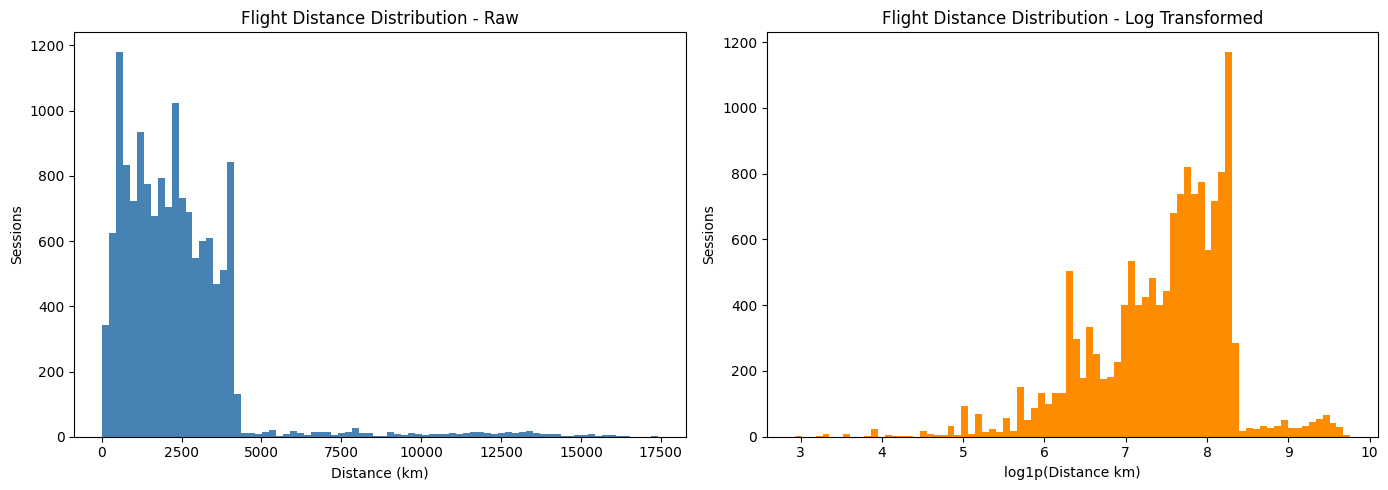

=== Distance Percentile Profile ===
   10th percentile:      543 km
   20th percentile:      832 km
   25th percentile:     1067 km
   33th percentile:     1343 km
   50th percentile:     2060 km
   66th percentile:     2654 km
   75th percentile:     3126 km
   80th percentile:     3413 km
   90th percentile:     3939 km
   95th percentile:     4125 km
   99th percentile:    12367 km


In [ ]:
# Distance Tiers - carried over from prior
# Visualize distance distribution to find natural breakpoints
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df1_flights['flight_distance_km'], bins=80, 
             color='steelblue', edgecolor='none')
axes[0].set_title('Flight Distance Distribution - Raw')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Sessions')

# Log transformed
axes[1].hist(np.log1p(df1_flights['flight_distance_km']), bins=80,
             color='darkorange', edgecolor='none')
axes[1].set_title('Flight Distance Distribution - Log Transformed')
axes[1].set_xlabel('log1p(Distance km)')
axes[1].set_ylabel('Sessions')

plt.tight_layout()
plt.show()

# Percentile profile
print("=== Distance Percentile Profile ===")
percentiles = [10, 20, 25, 33, 50, 66, 75, 80, 90, 95, 99]
for p in percentiles:
    val = np.percentile(df1_flights['flight_distance_km'].dropna(), p)
    print(f"  {p:>3}th percentile: {val:>8.0f} km")

---

# Observations Ver2:


Extracting from DF1 - cohort sessions only and includes lat/lon values  
Clear Bimodal distribution  
Two large groups and long right tail  
+/- 1000km and ~2200km groupings, then drop of and tail from 4000km  
Longest distance = 12456km  
5180 (prev. 5206) users with distance data  
- 5998 total users in cohort  
- 434 (prev. 432) never booked  
- 397 (prev. 360) users only booked Hotels or other reason? 

Bin considerations:  
'<1000km' = Short Domestic   
'1000-2500km' = Medium Domestic + regional Intl    
'2500-4500km' = Long haul Cross-continental  
'>4500km' = Ultra-long haul Intercontinental - Unique travel behavior+

Alt bin considerations: - may also require more data exploration at the user level  
No-Passport travelers = US only (or home airport country only - continental or otherwise)   
Continental Americas only = US, Canada, Central & South America  
International = From US/Canada to non continental destiantions > 1 trip
World Travelers = International > 1 trip  
  
- Version 1 observations held the same overall